# TOMATO WASTE REDUCTION

## Steps
-Data Importation
-Data Cleaning
-Exploratory Data Analysis
-Model Training
-Hyperparameter tuning
-Model comparism
-Feature importance analysis


In [5]:
#Importing necessary libraries

#data manipulation
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

#data processing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#degression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

#model evaluation
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

#model interpretation
from sklearn.inspection import permutation_importance

#statistical analysis
from scipy import stats




## Loading and analysing the Dataset

In [12]:

df = pd.read_csv('Nigeria_Tomato_Post_Harvest_Dataset.csv')

In [13]:
df.head()

,Farmer_ID,Farmer_Name,State,LGA,Farm_Size_Ha,Harvest_Date,Quantity_Harvested_Kg,Storage_Type,Temperature_C,Humidity_%,Distance_to_Market_Km,Transport_Mode,Delivery_Time_Hours,Quantity_Sold_Kg,Quantity_Spoiled_Kg,Spoilage_%,Selling_Price_Per_Kg,Revenue_NGN,Cold_Storage_Used
0,F0001,Musa Bello,Kano,Bunkure,1.2,1/18/2026,1894,NaN,20,66,200,Pickup,6.5,947,947,50.0,740,700780,No
1,F0002,John David,Jigawa,Hadejia,3.5,3/30/2026,1480,Cold Room,32,80,63,Truck,9.9,1397,83,5.6,686,958342,Yes
2,F0003,Musa Bello,Jigawa,Hadejia,6.8,6/14/2026,1141,NaN,32,52,154,Van,21.0,571,570,50.0,1104,630384,No
3,F0004,Ibrahim Ali,Kano,Kura,2.4,3/2/2026,3343,NaN,29,64,96,Van,10.8,2608,735,22.0,615,1603920,No
4,F0005,Mary James,Kaduna,Soba,7.6,3/22/2026,4212,NaN,33,84,56,Pickup,3.7,3666,546,13.0,710,2602860,No


In [14]:
df.tail()

,Farmer_ID,Farmer_Name,State,LGA,Farm_Size_Ha,Harvest_Date,Quantity_Harvested_Kg,Storage_Type,Temperature_C,Humidity_%,Distance_to_Market_Km,Transport_Mode,Delivery_Time_Hours,Quantity_Sold_Kg,Quantity_Spoiled_Kg,Spoilage_%,Selling_Price_Per_Kg,Revenue_NGN,Cold_Storage_Used
995,F0996,Grace Paul,Jigawa,Hadejia,8.0,5/24/2026,1689,NaN,29,63,263,Truck,7.4,845,844,50.0,956,807820,No
996,F0997,Grace Paul,Jigawa,Garki,1.5,1/10/2026,3224,Cold Room,28,90,256,Van,22.6,3181,43,1.3,1111,3534091,Yes
997,F0998,Musa Bello,Kaduna,Soba,5.7,4/2/2026,2120,NaN,19,62,93,Truck,10.9,1847,273,12.9,1108,2046476,No
998,F0999,Mary James,Jigawa,Garki,5.3,6/16/2026,2698,Warehouse,27,78,220,Van,17.9,1995,703,26.1,888,1771560,No
999,F1000,Musa Bello,Kano,Bunkure,7.0,1/16/2026,1498,Warehouse,20,80,297,Pickup,14.1,1264,234,15.6,525,663600,No


In [16]:
df.columns

Index(['Farmer_ID', 'Farmer_Name', 'State', 'LGA', 'Farm_Size_Ha',
       'Harvest_Date', 'Quantity_Harvested_Kg', 'Storage_Type',
       'Temperature_C', 'Humidity_%', 'Distance_to_Market_Km',
       'Transport_Mode', 'Delivery_Time_Hours', 'Quantity_Sold_Kg',
       'Quantity_Spoiled_Kg', 'Spoilage_%', 'Selling_Price_Per_Kg',
       'Revenue_NGN', 'Cold_Storage_Used'],
      dtype='str')

In [18]:
df.shape

(1000, 19)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Farmer_ID              1000 non-null   str    
 1   Farmer_Name            1000 non-null   str    
 2   State                  1000 non-null   str    
 3   LGA                    1000 non-null   str    
 4   Farm_Size_Ha           1000 non-null   float64
 5   Harvest_Date           1000 non-null   str    
 6   Quantity_Harvested_Kg  1000 non-null   int64  
 7   Storage_Type           661 non-null    str    
 8   Temperature_C          1000 non-null   int64  
 9   Humidity_%             1000 non-null   int64  
 10  Distance_to_Market_Km  1000 non-null   int64  
 11  Transport_Mode         1000 non-null   str    
 12  Delivery_Time_Hours    1000 non-null   float64
 13  Quantity_Sold_Kg       1000 non-null   int64  
 14  Quantity_Spoiled_Kg    1000 non-null   int64  
 15  Spoilage_%      

In [31]:
df.describe()

,Farm_Size_Ha,Quantity_Harvested_Kg,Temperature_C,Humidity_%,Distance_to_Market_Km,Delivery_Time_Hours,Quantity_Sold_Kg,Quantity_Spoiled_Kg,Spoilage_%,Selling_Price_Per_Kg,Revenue_NGN
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,5.541500,2798.462000,26.540000,69.947000,158.210000,12.232700,2343.828000,454.634000,20.299100,845.324000,1.979478e+06
std,2.633181,1299.773593,5.211868,11.903356,82.873493,6.672574,1304.327082,353.292893,16.856275,199.795023,1.220897e+06
min,1.000000,518.000000,18.000000,50.000000,10.000000,1.000000,259.000000,20.000000,0.500000,501.000000,1.315720e+05
25%,3.200000,1720.250000,22.000000,60.000000,88.000000,6.400000,1114.000000,118.750000,4.800000,672.500000,9.115095e+05
50%,5.600000,2823.000000,27.000000,70.000000,164.000000,12.300000,2336.500000,382.500000,16.450000,853.500000,1.855502e+06
75%,7.800000,3925.250000,31.000000,80.000000,229.000000,18.000000,3470.750000,751.250000,32.325000,1010.000000,2.835890e+06
max,10.000000,5000.000000,35.000000,90.000000,300.000000,24.000000,4930.000000,1196.000000,50.000000,1200.000000,5.696616e+06


In [32]:
#checking for missing values
df.isnull().sum()

Farmer_ID                  0
Farmer_Name                0
State                      0
LGA                        0
Farm_Size_Ha               0
Harvest_Date               0
Quantity_Harvested_Kg      0
Storage_Type             339
Temperature_C              0
Humidity_%                 0
Distance_to_Market_Km      0
Transport_Mode             0
Delivery_Time_Hours        0
Quantity_Sold_Kg           0
Quantity_Spoiled_Kg        0
Spoilage_%                 0
Selling_Price_Per_Kg       0
Revenue_NGN                0
Cold_Storage_Used          0
dtype: int64

In [33]:
#Checking for duplicate rows
df = df.drop_duplicates()

In [34]:
#Handling missing values
df['Storage_Type'].unique()

<StringArray>
[nan, 'Cold Room', 'Warehouse']
Length: 3, dtype: str

In [45]:
df['Storage_Type'].value_counts()

Storage_Type
Warehouse    680
Cold Room    320
Name: count, dtype: int64

In [49]:
#Filling up the missing values with mode because we cant drop the vital row 
mode_value = df['Storage_Type'].mode()[0]
df['Storage_Type'] = df['Storage_Type'].fillna(mode_value) 
inplace = True
    

In [50]:
#Checking if the filling worked

df.isnull().sum()

Farmer_ID                0
Farmer_Name              0
State                    0
LGA                      0
Farm_Size_Ha             0
Harvest_Date             0
Quantity_Harvested_Kg    0
Storage_Type             0
Temperature_C            0
Humidity_%               0
Distance_to_Market_Km    0
Transport_Mode           0
Delivery_Time_Hours      0
Quantity_Sold_Kg         0
Quantity_Spoiled_Kg      0
Spoilage_%               0
Selling_Price_Per_Kg     0
Revenue_NGN              0
Cold_Storage_Used        0
dtype: int64

In [51]:
#Converting data types

#converting harvest_date from string
df['Harvest_Date'] = pd.to_datetime(df['Harvest_Date'])

In [53]:
#Confirming the change

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Farmer_ID              1000 non-null   str           
 1   Farmer_Name            1000 non-null   str           
 2   State                  1000 non-null   str           
 3   LGA                    1000 non-null   str           
 4   Farm_Size_Ha           1000 non-null   float64       
 5   Harvest_Date           1000 non-null   datetime64[us]
 6   Quantity_Harvested_Kg  1000 non-null   int64         
 7   Storage_Type           1000 non-null   str           
 8   Temperature_C          1000 non-null   int64         
 9   Humidity_%             1000 non-null   int64         
 10  Distance_to_Market_Km  1000 non-null   int64         
 11  Transport_Mode         1000 non-null   str           
 12  Delivery_Time_Hours    1000 non-null   float64       
 13  Quantity_Sold_K

In [54]:
#Checking for outliers

#look at the numerical column
df.describe()

,Farm_Size_Ha,Harvest_Date,Quantity_Harvested_Kg,Temperature_C,Humidity_%,Distance_to_Market_Km,Delivery_Time_Hours,Quantity_Sold_Kg,Quantity_Spoiled_Kg,Spoilage_%,Selling_Price_Per_Kg,Revenue_NGN
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,5.541500,2026-03-31 19:07:40.800000,2798.462000,26.540000,69.947000,158.210000,12.232700,2343.828000,454.634000,20.299100,845.324000,1.979478e+06
min,1.000000,2026-01-01 00:00:00,518.000000,18.000000,50.000000,10.000000,1.000000,259.000000,20.000000,0.500000,501.000000,1.315720e+05
25%,3.200000,2026-02-14 00:00:00,1720.250000,22.000000,60.000000,88.000000,6.400000,1114.000000,118.750000,4.800000,672.500000,9.115095e+05
50%,5.600000,2026-04-01 00:00:00,2823.000000,27.000000,70.000000,164.000000,12.300000,2336.500000,382.500000,16.450000,853.500000,1.855502e+06
75%,7.800000,2026-05-17 00:00:00,3925.250000,31.000000,80.000000,229.000000,18.000000,3470.750000,751.250000,32.325000,1010.000000,2.835890e+06
max,10.000000,2026-06-30 00:00:00,5000.000000,35.000000,90.000000,300.000000,24.000000,4930.000000,1196.000000,50.000000,1200.000000,5.696616e+06
std,2.633181,NaN,1299.773593,5.211868,11.903356,82.873493,6.672574,1304.327082,353.292893,16.856275,199.795023,1.220897e+06


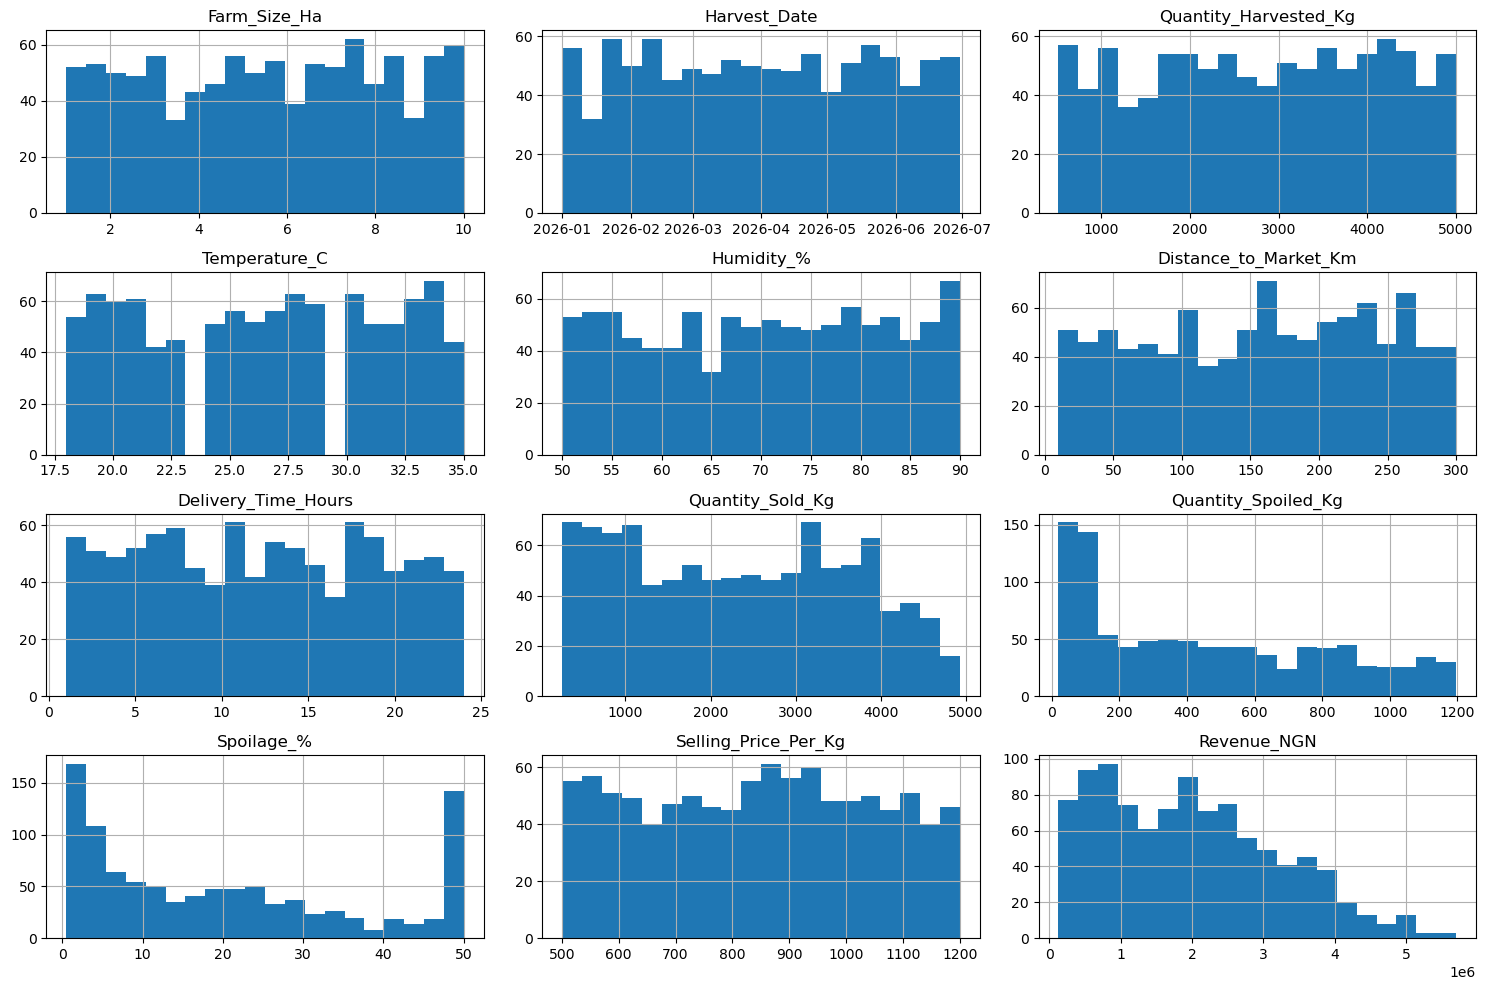

In [63]:
#Visualization

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

## Exploratory data analysis

#Here, we will be answering some questions with plots.


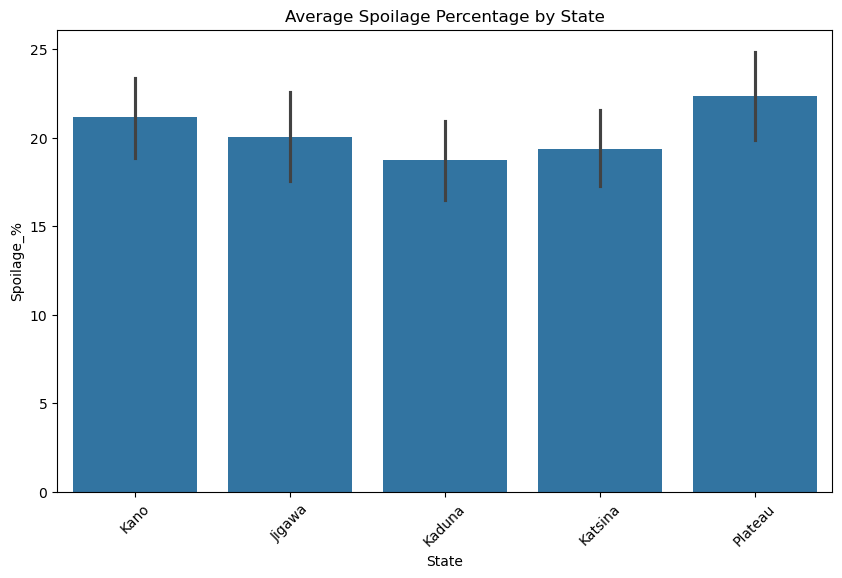

In [65]:
#What state has the highest spoilage?

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='State', y='Spoilage_%')
plt.xticks(rotation=45)
plt.title('Average Spoilage Percentage by State')
plt.show()

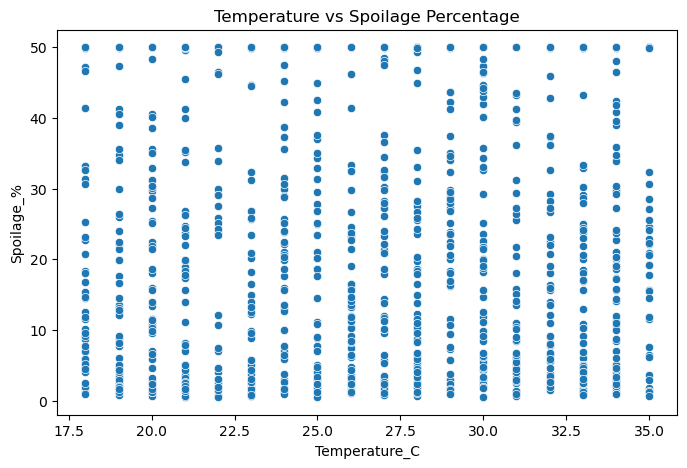

In [66]:
#Does temperature affect spoilage?

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Temperature_C', y='Spoilage_%')
plt.title('Temperature vs Spoilage Percentage')
plt.show()

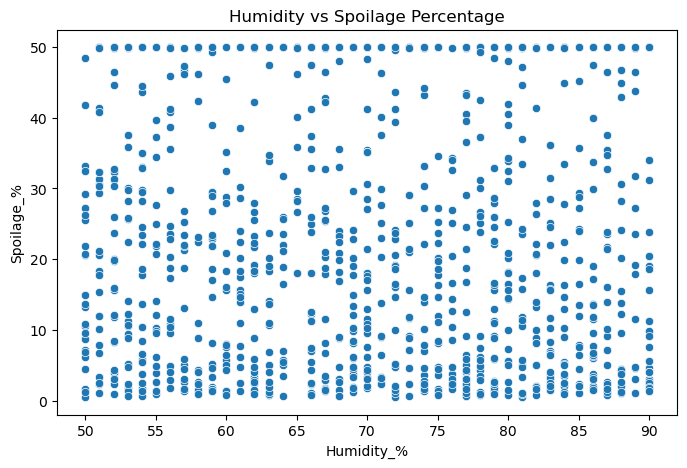

In [67]:
#Does humidity affect spoilage?
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Humidity_%', y='Spoilage_%')
plt.title('Humidity vs Spoilage Percentage')
plt.show()

Object `spoilage` not found.


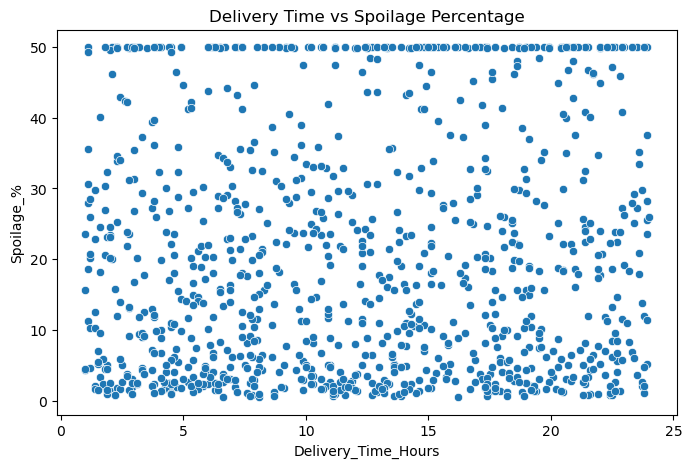

In [68]:
Does delivery time affect spoilage?
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Delivery_Time_Hours', y='Spoilage_%')
plt.title('Delivery Time vs Spoilage Percentage')
plt.show()

Object `spoilage` not found.


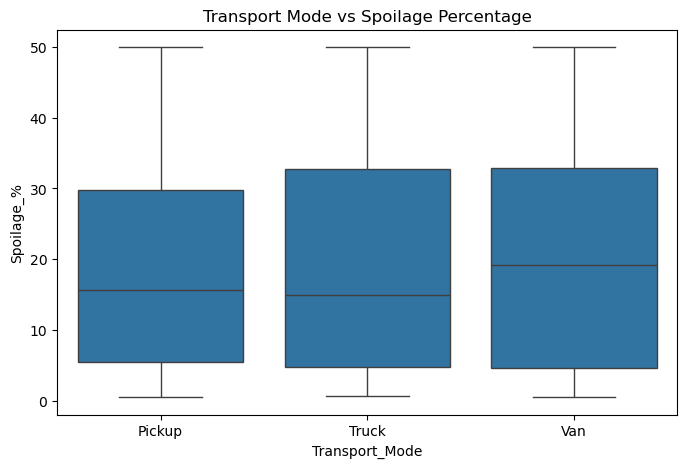

In [69]:
Does transport mode affect spoilage?
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Transport_Mode', y='Spoilage_%')
plt.title('Transport Mode vs Spoilage Percentage')
plt.show()

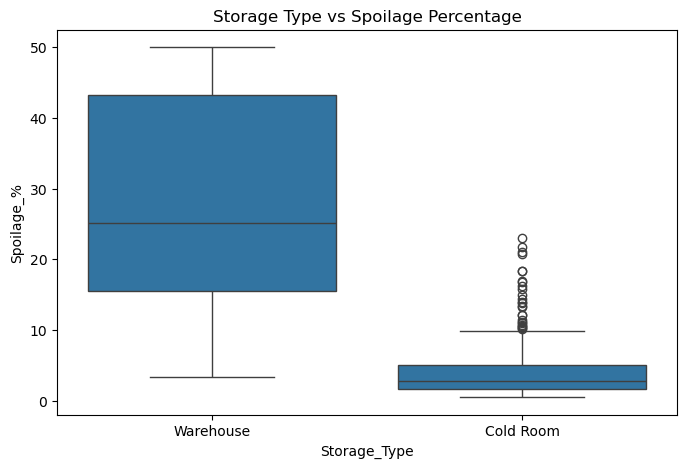

In [70]:
#Does storage type reduce spoilage?

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Storage_Type', y='Spoilage_%')
plt.title('Storage Type vs Spoilage Percentage')
plt.show()

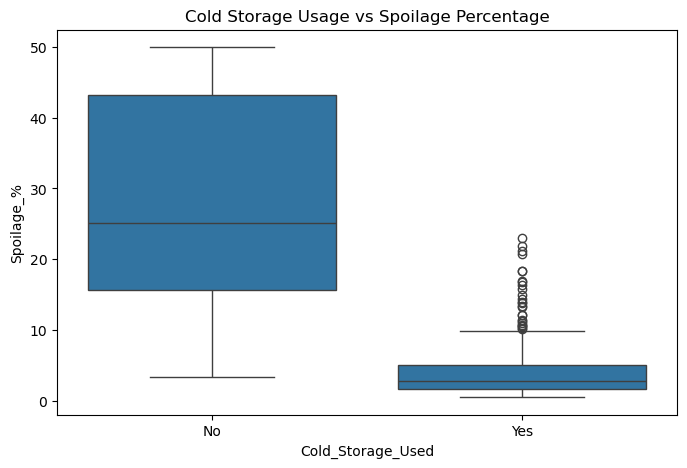

In [71]:
#Does cold storage help?
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Cold_Storage_Used', y='Spoilage_%')
plt.title('Cold Storage Usage vs Spoilage Percentage')
plt.show()

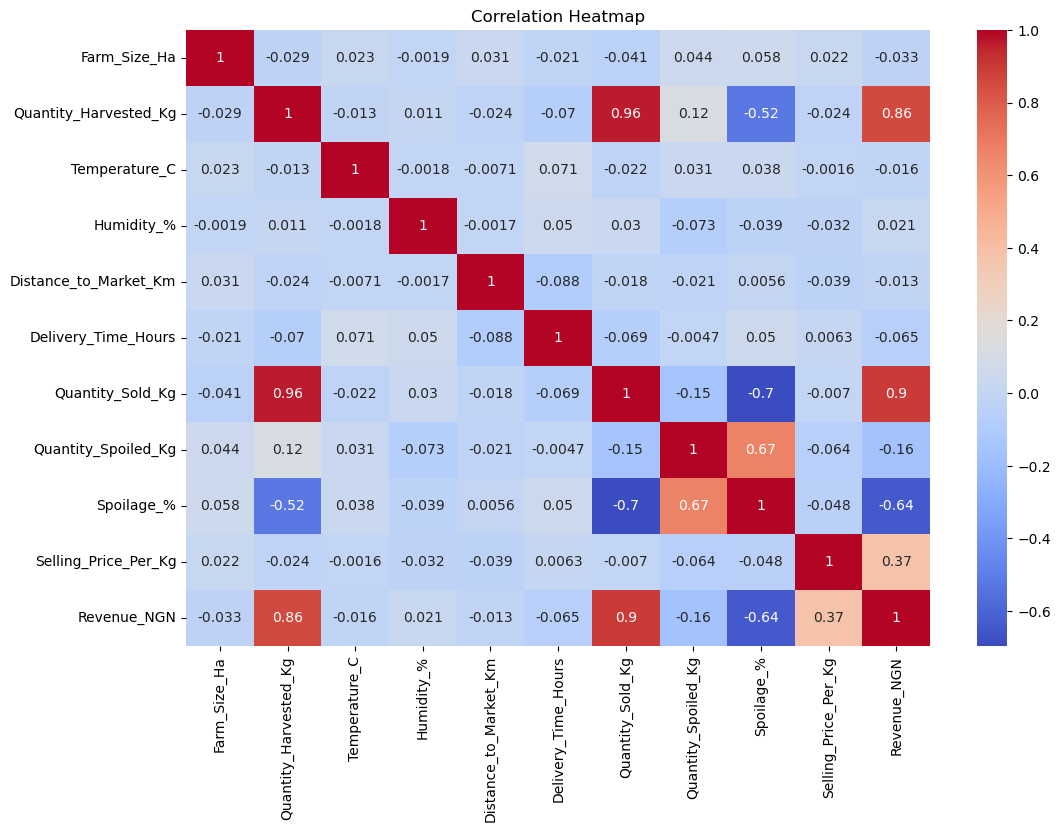

In [72]:
#Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Feture Engineering

In [74]:
#Here, we create new feature

df['loss_Kg'] = df['Quantity_Harvested_Kg'] - df['Quantity_Sold_Kg']

In [75]:
#checking to see if our new column has been updated
df.columns

Index(['Farmer_ID', 'Farmer_Name', 'State', 'LGA', 'Farm_Size_Ha',
       'Harvest_Date', 'Quantity_Harvested_Kg', 'Storage_Type',
       'Temperature_C', 'Humidity_%', 'Distance_to_Market_Km',
       'Transport_Mode', 'Delivery_Time_Hours', 'Quantity_Sold_Kg',
       'Quantity_Spoiled_Kg', 'Spoilage_%', 'Selling_Price_Per_Kg',
       'Revenue_NGN', 'Cold_Storage_Used', 'loss_Kg'],
      dtype='str')

In [76]:
df.head()

,Farmer_ID,Farmer_Name,State,LGA,Farm_Size_Ha,Harvest_Date,Quantity_Harvested_Kg,Storage_Type,Temperature_C,Humidity_%,Distance_to_Market_Km,Transport_Mode,Delivery_Time_Hours,Quantity_Sold_Kg,Quantity_Spoiled_Kg,Spoilage_%,Selling_Price_Per_Kg,Revenue_NGN,Cold_Storage_Used,loss_Kg
0,F0001,Musa Bello,Kano,Bunkure,1.2,2026-01-18,1894,Warehouse,20,66,200,Pickup,6.5,947,947,50.0,740,700780,No,947
1,F0002,John David,Jigawa,Hadejia,3.5,2026-03-30,1480,Cold Room,32,80,63,Truck,9.9,1397,83,5.6,686,958342,Yes,83
2,F0003,Musa Bello,Jigawa,Hadejia,6.8,2026-06-14,1141,Warehouse,32,52,154,Van,21.0,571,570,50.0,1104,630384,No,570
3,F0004,Ibrahim Ali,Kano,Kura,2.4,2026-03-02,3343,Warehouse,29,64,96,Van,10.8,2608,735,22.0,615,1603920,No,735
4,F0005,Mary James,Kaduna,Soba,7.6,2026-03-22,4212,Warehouse,33,84,56,Pickup,3.7,3666,546,13.0,710,2602860,No,546


In [77]:
#Dropping unnecessary columns

df = df.drop(['Farmer_ID', 'Farmer_Name'], axis=1)

In [78]:
df.columns

Index(['State', 'LGA', 'Farm_Size_Ha', 'Harvest_Date', 'Quantity_Harvested_Kg',
       'Storage_Type', 'Temperature_C', 'Humidity_%', 'Distance_to_Market_Km',
       'Transport_Mode', 'Delivery_Time_Hours', 'Quantity_Sold_Kg',
       'Quantity_Spoiled_Kg', 'Spoilage_%', 'Selling_Price_Per_Kg',
       'Revenue_NGN', 'Cold_Storage_Used', 'loss_Kg'],
      dtype='str')

In [79]:
# Define Target variable
y = df['Spoilage_%']

# Define feature matrix
X = df.drop('Spoilage_%', axis=1)

In [81]:
#Encoding categorical variables

X = pd.get_dummies(X, drop_first=True)